In [1]:
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
import snapatac2 as snap
import numpy as np
import pandas as pd
import os
import scanpy.external as sce
import seaborn as sns
from sklearn.metrics import silhouette_score
from hmmlearn import hmm
import numpy as np


In [2]:
import warnings
warnings.filterwarnings("ignore")


In [3]:
if os.path.exists('/data2st1/junyi/output/atac1112/100kbin_annotated.h5ad') == False:
    print("File not found, processing data...")
    files = [
    '/data1st2/hannan_25/data/snATAC_process/snATAC_01_bam/MC25A_PFC/',
    '/data1st2/hannan_25/data/snATAC_process/snATAC_01_bam/MC37A_AMY/',
    '/data1st2/hannan_25/data/snATAC_process/snATAC_01_bam/MC39C_HIP/',
    '/data1st2/hannan_25/data/snATAC_process/snATAC_01_bam/MC48D_HIP/',
    '/data1st2/hannan_25/data/snATAC_process/snATAC_01_bam/MC50B_AMY/',
    '/data1st2/hannan_25/data/snATAC_process/snATAC_01_bam/MC50B_HIP/',
    '/data1st2/hannan_25/data/snATAC_process/snATAC_01_bam/MC50B_PFC/',
    '/data1st2/hannan_25/data/snATAC_process/snATAC_01_bam/MC52E_AMY/',
    '/data1st2/hannan_25/data/snATAC_process/snATAC_01_bam/MC52E_PFC/',
    '/data1st2/hannan_25/data/snATAC_process/snATAC_01_bam/MW26A_PFC/',
    '/data1st2/hannan_25/data/snATAC_process/snATAC_01_bam/MW45A_HIP/',
    '/data1st2/hannan_25/data/snATAC_process/snATAC_01_bam/MW47A_AMY/',
    '/data1st2/hannan_25/data/snATAC_process/snATAC_01_bam/MW47A_HIP/',
    '/data1st2/hannan_25/data/snATAC_process/snATAC_01_bam/MW47A_PFC/',
    '/data1st2/hannan_25/data/snATAC_process/snATAC_01_bam/MW51A_AMY/',
    '/data1st2/hannan_25/data/snATAC_process/snATAC_01_bam/MW51A_HIP/',
    '/data1st2/hannan_25/data/snATAC_process/snATAC_01_bam/MW51A_PFC/',
    '/data1st2/hannan_25/data/snATAC_process/snATAC_01_bam/MW65A_AMY/'
    ]
    files = [ os.path.join(fl,"outs","fragments.tsv.gz") for fl in files]
    # Load the fragment file
    data = snap.pp.import_fragments(
        files,
        file = [  "/data2st1/junyi/output/atac1112/"+fl.split("/")[-3]+".h5ad" for fl in files]
        , chrom_sizes=snap.genome.mm10, 
        min_num_fragments=1000,
        sorted_by_barcode=False)

    snap.metrics.tsse(data, snap.genome.mm10)
    snap.pp.filter_cells(data, min_counts=3000, min_tsse=3, max_counts=100000)
    snap.pp.add_tile_matrix(data, bin_size=100000)
    #snap.pp.select_features(data, n_features=50000)
    # snap.pp.scrublet(adatas)
    # snap.pp.filter_doublets(adatas)
    [  "/data2st1/junyi/output/atac1112/"+fl.split("/")[-3]+".h5ad" for fl in files]
    adfiles={
    'MC37A_AMY':'/data2st1/junyi/output/atac1112/MC37A_AMY.h5ad',
    'MC39C_HIP':'/data2st1/junyi/output/atac1112/MC39C_HIP.h5ad',
    'MC48D_HIP':'/data2st1/junyi/output/atac1112/MC48D_HIP.h5ad',
    'MC50B_AMY':'/data2st1/junyi/output/atac1112/MC50B_AMY.h5ad',
    'MC50B_HIP':'/data2st1/junyi/output/atac1112/MC50B_HIP.h5ad',
    'MC50B_PFC':'/data2st1/junyi/output/atac1112/MC50B_PFC.h5ad',
    'MC52E_AMY':'/data2st1/junyi/output/atac1112/MC52E_AMY.h5ad',
    'MC52E_PFC':'/data2st1/junyi/output/atac1112/MC52E_PFC.h5ad',
    'MW45A_HIP':'/data2st1/junyi/output/atac1112/MW45A_HIP.h5ad',
    'MW47A_AMY':'/data2st1/junyi/output/atac1112/MW47A_AMY.h5ad',
    'MW47A_HIP':'/data2st1/junyi/output/atac1112/MW47A_HIP.h5ad',
    'MW47A_PFC':'/data2st1/junyi/output/atac1112/MW47A_PFC.h5ad',
    'MW51A_AMY':'/data2st1/junyi/output/atac1112/MW51A_AMY.h5ad',
    'MW51A_HIP':'/data2st1/junyi/output/atac1112/MW51A_HIP.h5ad',
    'MW51A_PFC':'/data2st1/junyi/output/atac1112/MW51A_PFC.h5ad',
    'MC25A_PFC':'/data2st1/junyi/output/atac1112/MC25A_PFC.h5ad',
    'MW26A_PFC':'/data2st1/junyi/output/atac1112/MW26A_PFC.h5ad',
    'MW65A_AMY':'/data2st1/junyi/output/atac1112/MW65A_AMY.h5ad',

    # 'MC25A_PFC':'/data2st1/junyi/output/atac0416/W25_0_1_Perfrontal.h5ad',
    # 'MW26A_PFC':'/data2st1/junyi/output/atac0416/W26_0_2_Perfrontal.h5ad'
    }

    # newfolder = "/data2st1/junyi/output/atac0627/"

    # # for each file ind adfiles, make a hard link to the file in newfolder
    # for name, adfile in adfiles.items():
    #     newfile = os.path.join(newfolder, name + ".h5ad")
    #     if not os.path.exists(newfile):
    #         os.link(adfile, newfile)
    #         print(f"Created hard link for {name} at {newfile}")
    #     else:
    #         print(f"File {newfile} already exists, skipping.")
    adatass = [ snap.read(k) for k in adfiles.values()]
    data = snap.AnnDataSet(
        adatas=[(name, adata) for (name), adata in zip(adfiles.keys(), adatass)],
        filename="output/atac1112/100kbin.h5ads"
    )
    adata_100k = data.to_adata()
    adata_100k.obs
    adata_100k.obs['barcode'] = adata_100k.obs.index
    df_meta_all = pd.read_csv('/data2st1/junyi/output/atac1112/ATACSC_3REGION_ALL_L2annoated.csv',index_col=0)
    adata_100k.obs.index = adata_100k.obs['sample']+":"+adata_100k.obs['barcode']
    adata_100k.obs['sample_barcode'] = adata_100k.obs['sample'] +":"+adata_100k.obs['barcode']
    adata_100k=adata_100k[df_meta_all.index]
    adata_100k.obs =df_meta_all
    adata_100k
    adata_100k_subset = adata_100k[~((adata_100k.obs['leiden_res_1.9']==14) & (adata_100k.obs['celltype.L1']=='Neuron'))]
    adata_100k_subset
    adata_100k_subset.obs['Region Subclass'] = adata_100k_subset.obs['celltype.L2'].astype(str)
    adata_100k_subset.obs['Region'] = adata_100k_subset.obs['Region'].replace('HIP','HPF')
    adata_100k_subset.obs.loc[adata_100k_subset.obs['Neurotransmitter_celltype']=='NN','Region Subclass'] = \
        adata_100k_subset.obs.loc[adata_100k_subset.obs['Neurotransmitter_celltype']=='NN','Region'].astype(str) +"_" + adata_100k_subset.obs.loc[adata_100k_subset.obs['Neurotransmitter_celltype']=='NN','Region Subclass'].astype(str)
    adata_100k_subset.obs['Region Suclass'] = adata_100k_subset.obs['Region Suclass'].str.replace(' ','_')
    adata_100k_subset.obs['Region Suclass'] = adata_100k_subset.obs['Region Suclass'].str.replace('/','-')
    adata_100k_subset.write_h5ad('/data2st1/junyi/output/atac1112/100kbin_annotated.h5ad')
else:
    print("File found, loading data...")
    adata_100k_subset = sc.read_h5ad('/data2st1/junyi/output/atac1112/100kbin_annotated.h5ad')

File found, loading data...


In [4]:
adata_100k_subset.obs['Sample Region Subclass'] = adata_100k_subset.obs['sample'].astype(str) + "_" + adata_100k_subset.obs['Region Subclass'].astype(str)

In [5]:
adata_100kbulk = sc.get.aggregate(
    adata_100k_subset,
    by='Sample Region Subclass',
    func='sum'
)   

In [6]:
adata_100kbulk.X=adata_100kbulk.layers['sum']
valid = adata_100kbulk.X.sum(axis=0) > 0
adata_100kbulk = adata_100kbulk[:, valid]
#sc.pp.normalize_total(adata_100kbulk, target_sum=1e6)


In [7]:
adata_100kbulk.obs['Region Subclass'] = adata_100kbulk.obs['Sample Region Subclass'].str[10:]
adata_100kbulk.obs['Region Subclass']= adata_100kbulk.obs['Region Subclass'].str.replace(' ','_')
adata_100kbulk.obs['Region Subclass']= adata_100kbulk.obs['Region Subclass'].str.replace('/','-')
# 


In [ ]:
for ct in adata_100kbulk.obs['Region Subclass'].unique():
    data_sub = adata_100kbulk[adata_100kbulk.obs['Region Subclass']==ct]
    # rows are samples, cols are bins
    data_sub.obs['Status'] = data_sub.obs['Sample Region Subclass'].str[:2]

    # Filter out bins with zero sum
    valid = data_sub.X.sum(axis=0) > 0
    data_sub = data_sub[:, valid]
    
    Z = (data_sub.X - data_sub.X.mean(axis=0)) / data_sub.X.std(axis=0)
    Z = np.nan_to_num(Z, nan=0.0)
    Z = Z.T
    Z.reshape(-1, 1).shape
    model = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=500)
    model.fit(Z)
    states = []
    for i in range(Z.shape[1]):
        Zi = Z[:, i].reshape(-1,1)
        states_i = model.predict(Zi)
        states.append(states_i)

    mean_s0 = data_sub.X.T[:, i][states[i] == 0].mean()
    mean_s1 = data_sub.X.T[:, i][states[i] == 1].mean()
    print(mean_s0, mean_s1)
    if mean_s0 > mean_s1:
        if data_sub.layers['sum'].shape == np.array(states).shape:
            data_sub.layers['state'] = np.array(states)    
        else:
            print("Shape mismatch")
    else:
        if data_sub.layers['sum'].shape == np.array(states).shape:
            data_sub.layers['state'] = 1-np.array(states)
    data_sub.write_h5ad(f'/data2st1/junyi/output/atac1112/compartment/compartment_{ct}.h5ad')

... storing 'Region Subclass' as categorical
... storing 'Status' as categorical


39.07439935632082 7.905532999422124


... storing 'Region Subclass' as categorical
... storing 'Status' as categorical


39.02667489744806 6.697275185069117


... storing 'Region Subclass' as categorical
... storing 'Status' as categorical


...

37.950664136622386 nan
37.950664136622386 nan


2025-11-28 15:40:02 - WARNING - Model is not converging.  Current: 4690.617339631844 is not greater than 5951.44114503408. Delta is -1260.8238054022368
... storing 'Region Subclass' as categorical
... storing 'Status' as categorical


37.95210444419143 0.0


2025-11-28 15:40:02 - WARNING - Model is not converging.  Current: 192059.44180658605 is not greater than 371575.6285452768. Delta is -179516.18673869077
... storing 'Region Subclass' as categorical


37.95066413662239 nan
nan 37.95066413662239


In [413]:
Z.std(axis=0)

array([0.])

In [414]:
import glob

In [415]:
adatafiles= glob.glob('/data2st1/junyi/output/atac1112/compartment/compartment_*.h5ad')

In [416]:
adata_list = []
for file in adatafiles:
    adata = sc.read_h5ad(file)
    adata_list.append(adata)
adata_compartment = anndata.concat(adata_list, axis=0)

In [417]:
comp = adata_compartment.layers["state"]     # shape = (6, 26350)
M = comp.T                          # 转为 (26350 bins, 6 samples)


In [418]:
from sklearn.cluster import KMeans

k = 25
km = KMeans(n_clusters=k, n_init=20, random_state=123)

cluster_labels = km.fit_predict(M)   # length = 26350


In [419]:
adata_compartment

AnnData object with n_obs × n_vars = 640 × 26350
    obs: 'Sample Region Subclass', 'Region Subclass', 'Status'
    layers: 'state', 'sum'

In [420]:
(1-M).sum()

15532526

In [421]:
M.sum()

1331474

In [422]:
adata_compartment.var['compartment_cluster'] = cluster_labels

RecursionError: maximum recursion depth exceeded

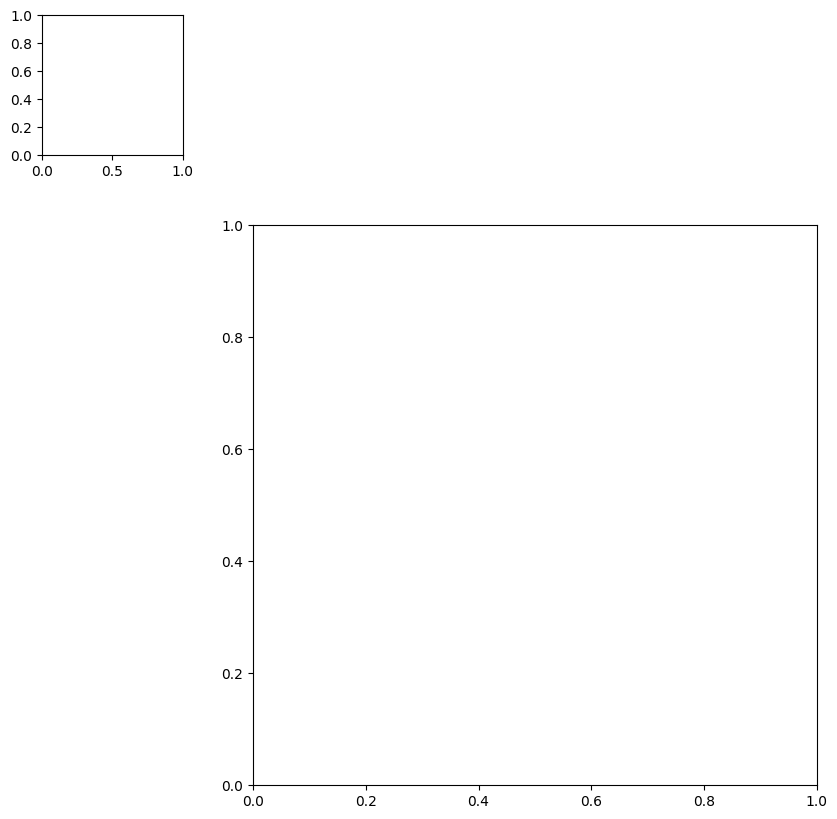

In [423]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.clustermap(M, row_cluster=True, col_cluster=True)


In [ ]:
sns.heatmap(centers, cmap="coolwarm", center=0.5)
plt.ylabel("Cluster ID")
plt.xlabel("Samples")
plt.show()


NameError: name 'centers' is not defined

In [ ]:
np.sum(np.array(states),axis=1)

array([826, 902, 845, 925, 830, 877])

In [ ]:
comp = data_sub.layers['state']        # shape = (6, 26350)
labels = data_sub.obs["Status"].values # e.g. ["MC","MC","MC","MW","MW","MW"]

In [ ]:
ctrl_mask = labels == "MW"
cums_mask = labels == "MC"

In [ ]:
print(ctrl_mask)
print(cums_mask)


[False False False  True  True  True]
[ True  True  True False False False]


In [ ]:
comp_ctrl = (comp[ctrl_mask].mean(axis=0) >= 0.5).astype(int)
comp_cums = (comp[cums_mask].mean(axis=0) >= 0.5).astype(int)


In [ ]:
RtA = np.sum((comp_ctrl == 0) & (comp_cums == 1))
AtR = np.sum((comp_ctrl == 1) & (comp_cums == 0))


In [ ]:
(comp_ctrl == 0) & (comp_cums == 1)

array([False, False, False, ..., False, False, False])

In [ ]:
AtR

1

In [ ]:
score = (RtA - AtR) / (RtA + AtR + 1e-10)
print("RtA:", RtA)
print("AtR:", AtR)
print("Compartment Dynamic Score:", score)


RtA: 2
AtR: 1
Compartment Dynamic Score: 0.3333333333222222


In [ ]:
Z = (adata_100kbulk.X - adata_100kbulk.X.mean(axis=0)) / adata_100kbulk.X.std(axis=0)

In [ ]:
comp = data_sub.layers["state"]     # shape = (6, 26350)
M = comp.T                          # 转为 (26350 bins, 6 samples)


In [ ]:
from sklearn.cluster import KMeans

k = 25
km = KMeans(n_clusters=k, n_init=20, random_state=123)

cluster_labels = km.fit_predict(M)   # length = 26350

In [ ]:
cluster_labels.min()

0